# Topic Modeling Profiles (Female-Focused & Character-Centric)

This notebook loads the pre-computed topic modeling results from `data/topic_modelling/final_model/` and generates the visualizations required for the report.

To align with the paper's framing of "feminine narratives of opium use" and to keep the figures visually distinct, compact, and ready for publication (no titles, as they are described in captions), we generate four key figures:
1. **Character Topic Gender Divergence**: A horizontal bar chart showing the difference in topic shares between Male and Female characters (`Male Character % - Female Character %`), showcasing the character-level gender gap.
2. **Author Gender Divergence for Female Characters**: A horizontal bar chart showing the difference in topic shares for **Female Characters** specifically between Female and Male Authors (`Female Author % - Male Author %`).
3. **Geography Divergence for Female Characters**: A horizontal bar chart showing the difference in topic shares for **Female Characters** specifically between British and American literature (`British % - American %`).
4. **Temporal Evolution of Female Character Topic Clusters**: A line plot showing how the four thematic clusters evolve chronologically specifically for **Female Characters** over the four historical periods (1850–1929).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up clean aesthetic style
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

def format_topic_label(label, max_words=3):
    """Formats the topic label to look clean in figures (e.g. 'Topic 12: captain, ship, colonel...')"""
    parts = label.split(': ')
    if len(parts) != 2:
        return label
    topic_num = parts[0]
    words = parts[1].split(', ')
    words_truncated = ', '.join(words[:max_words])
    if len(words) > max_words:
        words_truncated += '...'
    return f"Topic {topic_num} ({words_truncated})"

## 1) Topic Divergence by Character Gender (The Gender Gap)

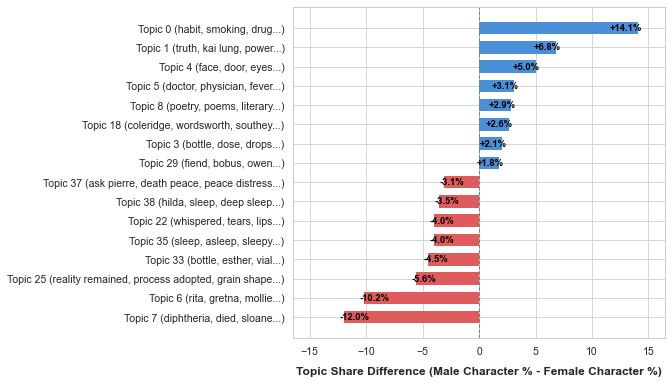

In [2]:
df_assigned = pd.read_csv('../../data/topic_modelling/final_model/final_topics_by_assigned_gender.csv')
df_assigned["Assigned_Gender_Group"] = df_assigned["Assigned_Gender_Group"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()
df_assigned = df_assigned[df_assigned['bertopic_topic'] != -1]  # Exclude outliers

df_gender_clean = df_assigned[df_assigned['Assigned_Gender_Group'].isin(['Male', 'Female'])]
pivot_gender = df_gender_clean.pivot(index='topic_label', columns='Assigned_Gender_Group', values='topic_share').fillna(0)
pivot_gender['diff'] = (pivot_gender['Male'] - pivot_gender['Female']) * 100

top_male = pivot_gender.sort_values('diff', ascending=False).head(8)
top_female = pivot_gender.sort_values('diff', ascending=True).head(8)
divergence_df = pd.concat([top_male, top_female]).sort_values('diff', ascending=False)

divergence_df.index = [format_topic_label(label) for label in divergence_df.index]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ['#4A90D9' if val >= 0 else '#E05B5B' for val in divergence_df['diff']]
bars = ax.barh(divergence_df.index, divergence_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference (Male Character % - Female Character %)', fontsize=12, fontweight='bold', labelpad=10)
ax.invert_yaxis()
ax.set_xlim(-16.5, 16.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -0.4 if width < 0 else 0.4
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=9.5, fontweight='semibold',
            color='black' if abs(width) > 0.5 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_gender_divergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 2) Topic Divergence by Author Gender for Female Characters

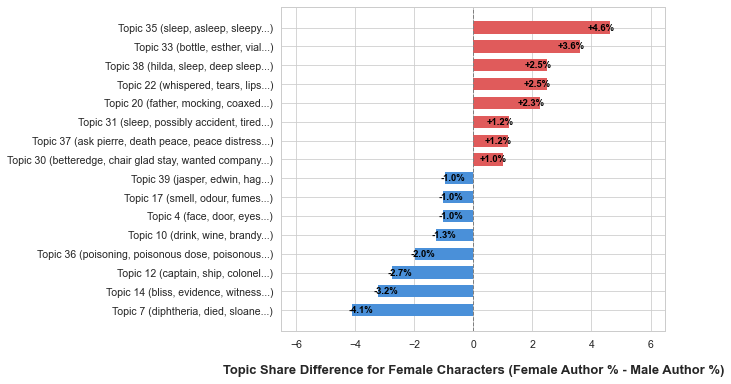

In [3]:
df_raw = pd.read_csv('../../data/topic_modelling/final_model/sentence_context_bertopic_tuned_final_document_topics.csv')
df_summary = pd.read_csv('../../data/topic_modelling/final_model/sentence_context_bertopic_tuned_final_topic_summary.csv')

df_raw["Author_Gender_Group"] = df_raw["Author Gender"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip().str.lower()
df_raw["Assigned_Gender_Group"] = df_raw["Assigned_Gender"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()

topic_to_label = df_summary.set_index('bertopic_topic')['top_terms'].to_dict()

df_female_author = df_raw[
    (df_raw["Assigned_Gender_Group"] == "Female") &
    (df_raw["bertopic_topic"] != -1) &
    (df_raw["Author_Gender_Group"].isin(["male", "female"]))
].copy()

df_female_author['topic_label'] = df_female_author['bertopic_topic'].map(lambda t: f"{t}: {topic_to_label.get(t, '')}")

grouped_author = df_female_author.groupby(['Author_Gender_Group', 'topic_label']).size().unstack(fill_value=0)
totals_author = df_female_author.groupby('Author_Gender_Group').size()
shares_author = (grouped_author.div(totals_author, axis=0) * 100).T
shares_author['diff'] = shares_author['female'] - shares_author['male']

top_female_author = shares_author.sort_values('diff', ascending=False).head(8)
top_male_author = shares_author.sort_values('diff', ascending=True).head(8)
author_df = pd.concat([top_female_author, top_male_author]).sort_values('diff', ascending=False)

author_df.index = [format_topic_label(label) for label in author_df.index]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ['#E05B5B' if val >= 0 else '#4A90D9' for val in author_df['diff']]
bars = ax.barh(author_df.index, author_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference for Female Characters (Female Author % - Male Author %)', fontsize=13, fontweight='bold', labelpad=15)
ax.invert_yaxis()
ax.set_xlim(-6.5, 6.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -0.15 if width < 0 else 0.15
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=9.5, fontweight='semibold',
            color='black' if abs(width) > 0.3 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_author_divergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 3) Topic Geography Divergence for Female Characters (British vs. American)

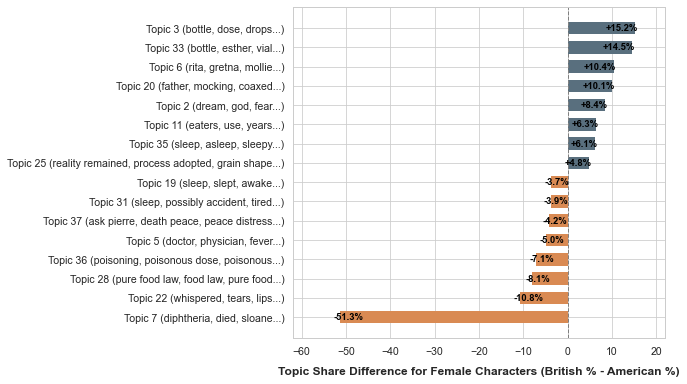

In [4]:
df_combined = pd.read_csv('../../data/topic_modelling/final_model/final_topics_by_assigned_gender_locc_period.csv')
df_combined["Assigned_Gender_Group"] = df_combined["Assigned_Gender_Group"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()
df_combined = df_combined[df_combined['bertopic_topic'] != -1]  # Exclude outliers

df_female_locc = df_combined[
    (df_combined["Assigned_Gender_Group"] == "Female") &
    (df_combined["LoCC_Display"].isin(["PR", "PS"]))
].copy()

pivot_locc = df_female_locc.pivot_table(index='topic_label', columns='LoCC_Display', values='topic_share', aggfunc='sum').fillna(0)
pivot_locc['diff'] = (pivot_locc['PR'] - pivot_locc['PS']) * 100

top_pr = pivot_locc.sort_values('diff', ascending=False).head(8)
top_ps = pivot_locc.sort_values('diff', ascending=True).head(8)
locc_df = pd.concat([top_pr, top_ps]).sort_values('diff', ascending=False)

locc_df.index = [format_topic_label(label) for label in locc_df.index]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ['#596F7E' if val >= 0 else '#D98A53' for val in locc_df['diff']]
bars = ax.barh(locc_df.index, locc_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference for Female Characters (British % - American %)', fontsize=12, fontweight='bold', labelpad=10)
ax.invert_yaxis()
ax.set_xlim(-62, 22)
ax.tick_params(axis='both', which='major', labelsize=10.5)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -1.5 if width < 0 else 0.6
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=9.5, fontweight='semibold',
            color='black' if abs(width) > 1.0 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_locc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 4) Historical Evolution of Female Character Topic Clusters

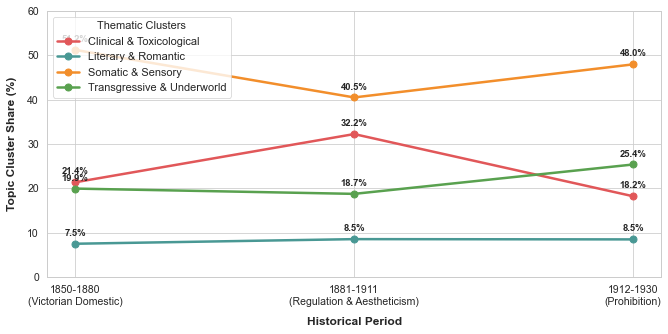

In [5]:
df_female_period = df_raw[(df_raw["Assigned_Gender"].fillna("Unknown").astype(str).str.strip() == "Female") & (df_raw["bertopic_topic"] != -1)].copy()

# Define the 3 historical eras
def get_historical_era(year):
    if pd.isna(year): return np.nan
    if year <= 1880: return "1850-1880\n(Victorian Domestic)"
    elif year <= 1911: return "1881-1911\n(Regulation & Aestheticism)"
    else: return "1912-1930\n(Prohibition)"

df_female_period['Era'] = df_female_period['Published Year'].apply(get_historical_era)
df_female_period = df_female_period.dropna(subset=['Era'])

clusters = {
    'Clinical & Toxicological': [3, 5, 7, 14, 33, 36, 42],
    'Somatic & Sensory': [0, 2, 4, 9, 10, 13, 15, 16, 17, 19, 22, 25, 27, 31, 34, 35, 37, 38, 43],
    'Literary & Romantic': [1, 8, 11, 18, 21, 24, 30, 40, 41],
    'Transgressive & Underworld': [6, 12, 20, 23, 26, 28, 29, 32, 39]
}

topic_to_cluster = {}
for cluster_name, topics in clusters.items():
    for t in topics:
        topic_to_cluster[t] = cluster_name

df_female_period['cluster'] = df_female_period['bertopic_topic'].map(topic_to_cluster)
df_female_period = df_female_period.dropna(subset=['cluster'])

grouped_period = df_female_period.groupby(['Era', 'cluster']).size().unstack(fill_value=0)
period_totals = df_female_period.groupby('Era').size()
shares = grouped_period.div(period_totals, axis=0) * 100

# Ensure chronological order
era_order = ["1850-1880\n(Victorian Domestic)", "1881-1911\n(Regulation & Aestheticism)", "1912-1930\n(Prohibition)"]
shares = shares.reindex(era_order)

fig, ax = plt.subplots(figsize=(9.5, 4.8))

colors = {
    'Clinical & Toxicological': '#E15759',  # soft red
    'Somatic & Sensory': '#F28E2B',         # soft orange
    'Literary & Romantic': '#499894',        # teal
    'Transgressive & Underworld': '#59A14F'  # soft green
}

for col in shares.columns:
    ax.plot(shares.index, shares[col], marker='o', linewidth=2.5, markersize=7, 
            color=colors[col], label=col)

for col in shares.columns:
    for x, y in zip(shares.index, shares[col]):
        ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), 
                    ha='center', fontsize=9.5, fontweight='semibold')

ax.set_ylabel('Topic Cluster Share (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Historical Period', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylim(0, 60)
ax.tick_params(axis='both', which='major', labelsize=10.5)
ax.legend(title='Thematic Clusters', title_fontsize=11, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('../../data/snippets/topic_temporal_evolution.png', dpi=200, bbox_inches='tight')
plt.show()